In [3]:
import pandas as pd

df = pd.read_csv("C:/Users/esrak/Desktop/PROJELER/football-talent-identifier/data/players_21.csv")

df.head()



,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club_name,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,33,1987-06-24,170,72,Argentina,FC Barcelona,...,66+3,65+3,65+3,65+3,66+3,62+3,52+3,52+3,52+3,62+3
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,35,1985-02-05,187,83,Portugal,Juventus,...,65+3,61+3,61+3,61+3,65+3,61+3,54+3,54+3,54+3,61+3
2,200389,https://sofifa.com/player/200389/jan-oblak/210002,J. Oblak,Jan Oblak,27,1993-01-07,188,87,Slovenia,Atlético Madrid,...,32+3,36+3,36+3,36+3,32+3,32+3,33+3,33+3,33+3,32+3
3,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,31,1988-08-21,184,80,Poland,FC Bayern München,...,64+3,65+3,65+3,65+3,64+3,61+3,60+3,60+3,60+3,61+3
4,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,28,1992-02-05,175,68,Brazil,Paris Saint-Germain,...,67+3,62+3,62+3,62+3,67+3,62+3,49+3,49+3,49+3,62+3


In [11]:
# En genç ve potansiyelli oyuncular
# En önemli sütunları seç
df_filtered = df[['short_name', 'age', 'overall', 'potential', 'player_positions', 'club_name']]

# Sıralama: önce potansiyeli yüksek olan, sonra genç olan
df_sorted = df_filtered.sort_values(by=['potential', 'age'], ascending=[False, True])

# En iyi 20 oyuncuya bak
df_sorted.head(20)


,short_name,age,overall,potential,player_positions,club_name
6,K. Mbappé,21,90,95,"ST, LW, RW",Paris Saint-Germain
366,Vinícius Jr.,19,80,93,LW,Real Madrid
28,J. Sancho,20,87,93,"RM, LM, CAM",Borussia Dortmund
272,João Félix,20,81,93,"CF, ST",Atlético Madrid
62,K. Havertz,21,85,93,"CAM, RM, CF",Chelsea
2,J. Oblak,27,91,93,GK,Atlético Madrid
7,M. ter Stegen,28,90,93,GK,FC Barcelona
0,L. Messi,33,93,93,"RW, ST, CF",FC Barcelona
99,E. Haaland,19,84,92,ST,Borussia Dortmund
64,M. de Ligt,20,85,92,CB,Juventus


In [9]:
#KEŞFEDİLECEK GENÇ YETENEKLER
# 21 yaş altı ve potansiyeli 85 üzeri olan oyuncuları seç
top_youth = df_filtered[(df_filtered['age'] <= 21) & (df_filtered['potential'] >= 85)]

# Potansiyeline göre sırala
top_youth = top_youth.sort_values(by='potential', ascending=False)

top_youth.head(15)


,short_name,age,overall,potential,player_positions,club_name
6,K. Mbappé,21,90,95,"ST, LW, RW",Paris Saint-Germain
62,K. Havertz,21,85,93,"CAM, RM, CF",Chelsea
366,Vinícius Jr.,19,80,93,LW,Real Madrid
28,J. Sancho,20,87,93,"RM, LM, CAM",Borussia Dortmund
272,João Félix,20,81,93,"CF, ST",Atlético Madrid
29,T. Alexander-Arnold,21,87,92,RB,Liverpool
63,G. Donnarumma,21,85,92,GK,Milan
64,M. de Ligt,20,85,92,CB,Juventus
99,E. Haaland,19,84,92,ST,Borussia Dortmund
898,S. Tonali,20,77,91,"CDM, CM",Milan


In [13]:
# Genç oyuncuların pozisyon dağılımı
top_youth['player_positions'].value_counts().head(10)


player_positions
CB         15
ST         11
CAM, CM     6
RW, LW      6
CDM, CM     5
RW          5
RB          5
CM          4
CM, CDM     4
GK          4
Name: count, dtype: int64

In [15]:
# Hangi kulüpler en çok potansiyelli genç barındırıyor?
top_youth['club_name'].value_counts().head(10)


club_name
FC Barcelona           6
Borussia Dortmund      6
Sporting CP            6
Arsenal                6
Chelsea                6
Real Madrid            5
Bayer 04 Leverkusen    5
Shakhtar Donetsk       4
Ajax                   4
SL Benfica             4
Name: count, dtype: int64

In [17]:
#POTANSİYEL VE YAŞ GRAFİĞİ

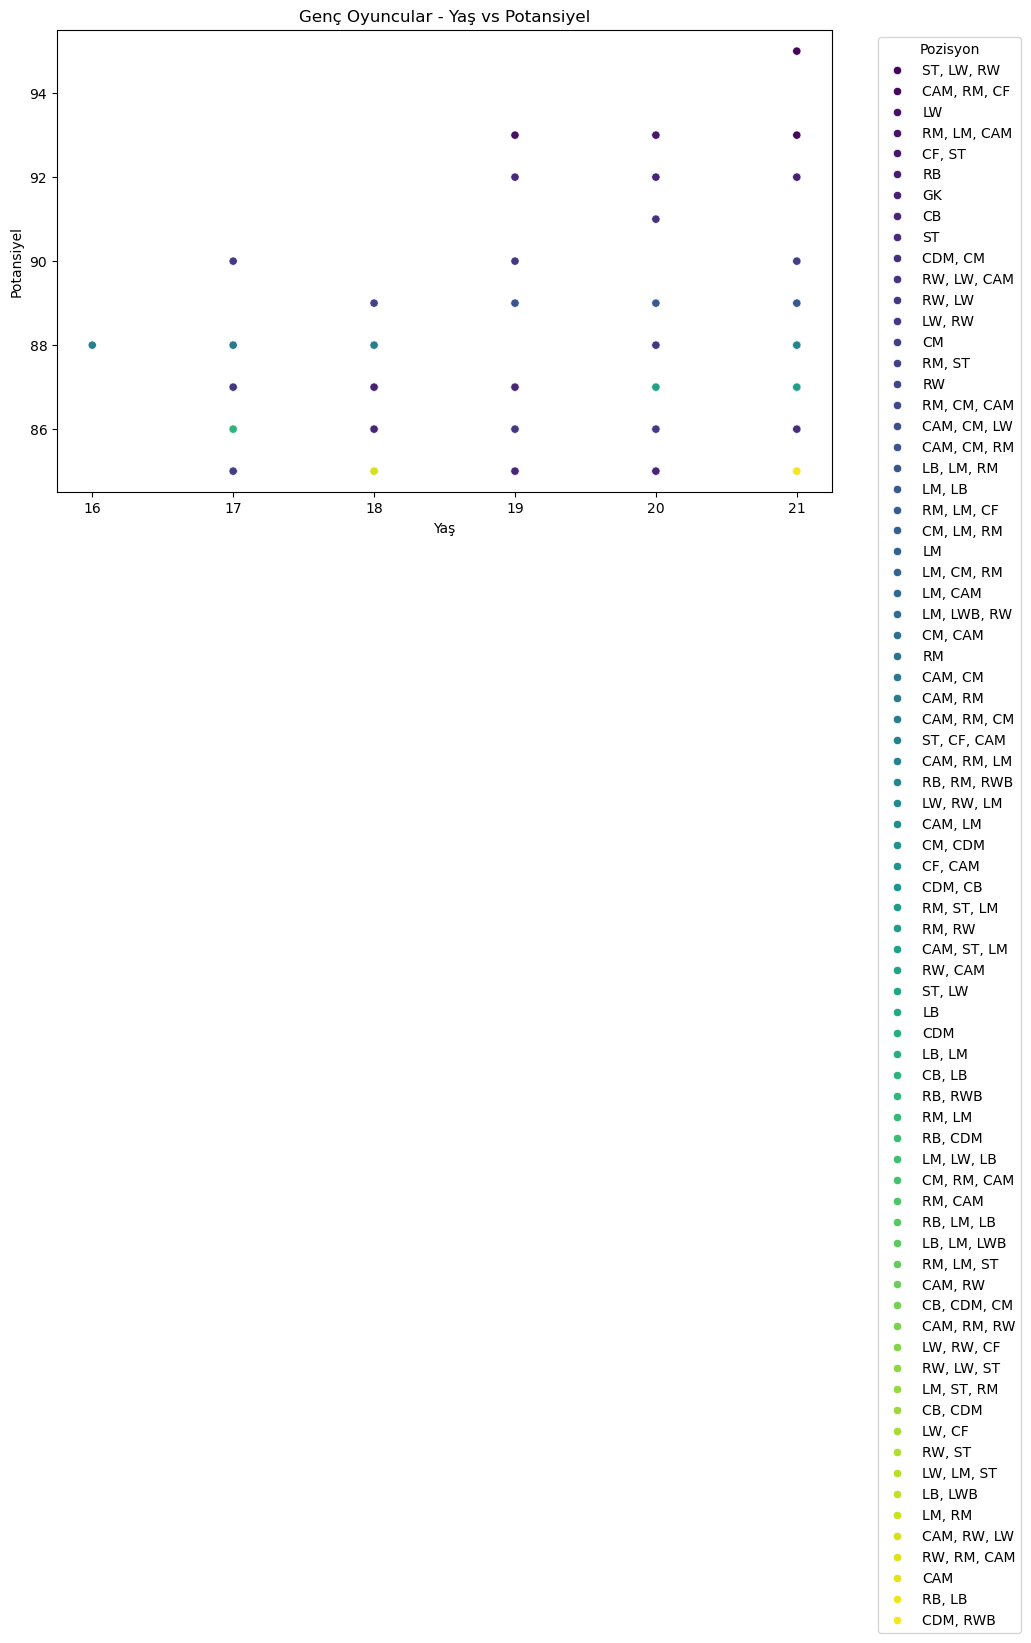

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
# Grafik boyutu
plt.figure(figsize=(10, 6))

sns.scatterplot(data=top_youth, x='age', y='potential', hue='player_positions', palette='viridis')

plt.title("Genç Oyuncular - Yaş vs Potansiyel")
plt.xlabel("Yaş")
plt.ylabel("Potansiyel")
plt.legend(title="Pozisyon", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()


In [32]:
import os

# Hedef klasörü oluşturalım.
os.makedirs("../data", exist_ok=True)

# CSV dosyasını kaydet
top_youth.to_csv("../data/genclik_yetenek_listesi.csv", index=False)



In [38]:
!pip install openpyxl
top_youth.to_excel("../data/genclik_yetenek_listesi.xlsx", index=False)
